# MatchMind - Controlled Football Metadata Ablation

This notebook performs a controlled ablation study on the textual metadata used for semantic retrieval in MatchMind.

Notebook 04 showed that football-aware chunking was a strong retrieval candidate, especially at Top-3 and Top-5.

The first version of Notebook 05 then compared:

```text
Baseline football-aware
vs
Metadata-enriched football-aware
```

and found that metadata helped some temporal queries but reduced several aggregate retrieval metrics.

However, that experiment had an important confounding factor:

```text
metadata was added
AND
chunk boundaries changed
```

because the enriched header consumed additional tokens.

The baseline corpus contained fewer chunks than the enriched corpus, so the experiment did not isolate the effect of metadata alone.

## Objective

This corrected experiment compares three representations:

```text
A. Baseline
B. Temporal metadata only
C. Full metadata
```

using **exactly the same event groups and chunk boundaries**.

The only difference between the three representations is the text added to the chunk header.

### A. Baseline

```text
Possession 228. Argentina.
```

### B. Temporal metadata only

```text
Possession 228. Argentina.
Period: Second Extra Time.
Match phase: Extra Time.
```

### C. Full metadata

```text
Possession 228. Argentina.
Period: Second Extra Time.
Match phase: Extra Time.
Play pattern: Regular Play.
```

Everything else remains fixed:

```text
same match
same embedding model
same event groups
same chunk boundaries
same 220-token maximum
same event overlap
same benchmark
same ground truth
same retrieval metrics
```

This creates a true metadata ablation study.

## 1. Project setup

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd()

if (cwd / "src").exists() and (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists() and (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the MatchMind project root. "
        "Start Jupyter from the project root or the notebooks directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/eldisymeraj/Documents/GitHub/MatchMind


## 2. Imports

No new dependency is required.

In [2]:
from collections import defaultdict
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer

from src.data.statsbomb_loader import load_events
from src.text.event_formatter import (
    build_event_documents,
    build_possession_documents,
)

print("Imports loaded successfully.")

/Users/eldisymeraj/Documents/GitHub/MatchMind/matchmind-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports loaded successfully.


## 3. Load the match corpus

The same 2022 FIFA World Cup final used throughout MatchMind is reused.

In [3]:
MATCH_ID = 3869685

events = load_events(MATCH_ID)

event_documents = build_event_documents(
    events,
    include_location=False,
    include_shootout=False,
)

possession_documents = build_possession_documents(
    events,
    include_location=False,
    include_shootout=False,
)

print(f"Raw events: {len(events)}")
print(f"Event documents: {len(event_documents)}")
print(f"Possession documents: {len(possession_documents)}")

Raw events: 4407
Event documents: 3252
Possession documents: 246


## 4. Load the same embedding model

The embedding model remains unchanged so that metadata is the main experimental variable.

In [4]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
embedding_model = SentenceTransformer(MODEL_NAME)

MAX_SEQUENCE_LENGTH = embedding_model.max_seq_length
CHUNK_TOKEN_BUDGET = 220
EVENT_OVERLAP = 1

print(f"Model: {MODEL_NAME}")
print(f"Maximum sequence length: {MAX_SEQUENCE_LENGTH}")
print(f"Chunk token budget: {CHUNK_TOKEN_BUDGET}")
print(f"Event overlap: {EVENT_OVERLAP}")

Model: sentence-transformers/all-MiniLM-L6-v2
Maximum sequence length: 256
Chunk token budget: 220
Event overlap: 1


# Part I - Define Football Metadata

## 5. Period names and broader match phases

StatsBomb uses numerical periods.

We convert them into explicit football language that may better match natural-language user questions.

In [5]:
PERIOD_NAMES = {
    1: "First Half",
    2: "Second Half",
    3: "First Extra Time",
    4: "Second Extra Time",
    5: "Penalty Shootout",
}

MATCH_PHASES = {
    1: "Regulation Time",
    2: "Regulation Time",
    3: "Extra Time",
    4: "Extra Time",
    5: "Penalty Shootout",
}


def get_period_name(period: int | None) -> str:
    """Return the human-readable football period name."""

    if period is None:
        return "Unknown"

    return PERIOD_NAMES.get(
        int(period),
        "Unknown",
    )


def get_match_phase(period: int | None) -> str:
    """Return the broader football match phase."""

    if period is None:
        return "Unknown"

    return MATCH_PHASES.get(
        int(period),
        "Unknown",
    )

In [6]:
for period in range(1, 6):
    print(
        period,
        "->",
        get_period_name(period),
        "|",
        get_match_phase(period),
    )

1 -> First Half | Regulation Time
2 -> Second Half | Regulation Time
3 -> First Extra Time | Extra Time
4 -> Second Extra Time | Extra Time
5 -> Penalty Shootout | Penalty Shootout


## 6. Token counting helper

In [7]:
def count_tokens(text: str) -> int:
    """Count tokenizer tokens without truncating the input text."""

    return len(
        tokenizer(
            text,
            add_special_tokens=True,
            truncation=False,
        )["input_ids"]
    )

# Part II - Define the Three Header Representations

## 7. Baseline header

In [8]:
def build_baseline_header(
    *,
    possession_id: int,
    possession_team: str,
    period: int | None,
    play_pattern: str | None,
) -> str:
    """Create the original minimal football-aware header."""

    return (
        f"Possession {possession_id}. "
        f"{possession_team}."
    )

## 8. Temporal-only header

This representation adds only metadata directly related to match time and phase.

It intentionally excludes `Play pattern`.

In [9]:
def build_temporal_header(
    *,
    possession_id: int,
    possession_team: str,
    period: int | None,
    play_pattern: str | None,
) -> str:
    """Create a header containing only temporal football metadata."""

    return "\n".join([
        f"Possession {possession_id}. {possession_team}.",
        f"Period: {get_period_name(period)}.",
        f"Match phase: {get_match_phase(period)}.",
    ])

## 9. Full metadata header

This reproduces the richer representation tested previously.

It adds `Play pattern` on top of the temporal fields.

In [10]:
def build_full_header(
    *,
    possession_id: int,
    possession_team: str,
    period: int | None,
    play_pattern: str | None,
) -> str:
    """Create a header containing temporal and play-pattern metadata."""

    lines = [
        f"Possession {possession_id}. {possession_team}.",
        f"Period: {get_period_name(period)}.",
        f"Match phase: {get_match_phase(period)}.",
    ]

    if play_pattern:
        lines.append(
            f"Play pattern: {play_pattern}."
        )

    return "\n".join(lines)

In [11]:
example_document = possession_documents[0]

header_kwargs = {
    "possession_id": example_document["possession_id"],
    "possession_team": example_document["possession_team"],
    "period": example_document["period"],
    "play_pattern": example_document["play_pattern"],
}

print("BASELINE")
print(build_baseline_header(**header_kwargs))

print("\nTEMPORAL ONLY")
print(build_temporal_header(**header_kwargs))

print("\nFULL METADATA")
print(build_full_header(**header_kwargs))

BASELINE
Possession 2. France.

TEMPORAL ONLY
Possession 2. France.
Period: First Half.
Match phase: Regulation Time.

FULL METADATA
Possession 2. France.
Period: First Half.
Match phase: Regulation Time.
Play pattern: From Kick Off.


# Part III - Build Shared Chunk Boundaries

## 10. Why shared boundaries are necessary

The previous metadata experiment produced different numbers of chunks because the enriched header consumed more tokens.

That means two variables changed simultaneously:

```text
text metadata
+
event grouping
```

This notebook removes that confounding factor.

We first create one canonical segmentation of each possession.

The segmentation is calculated using the **largest header**, the full metadata representation.

Therefore, if the full metadata version fits within 220 tokens, the shorter baseline and temporal-only versions will also fit.

The resulting event groups are then reused unchanged for all three representations.

## 11. Build canonical event groups

Each canonical group stores complete football events but does not yet define the final text representation.

In [12]:
def build_shared_event_groups(
    event_docs: list[dict],
    max_tokens: int = CHUNK_TOKEN_BUDGET,
    overlap_events: int = EVENT_OVERLAP,
) -> list[dict]:
    """
    Build shared event groups using the most verbose header.

    All later representations reuse these exact event groups so that
    metadata can be evaluated without changing chunk boundaries.
    """

    if max_tokens <= 0:
        raise ValueError("max_tokens must be greater than zero.")

    if overlap_events < 0:
        raise ValueError("overlap_events cannot be negative.")

    events_by_possession = defaultdict(list)

    for document in event_docs:
        possession_id = document.get("possession_id")

        if possession_id is not None:
            events_by_possession[possession_id].append(document)

    groups = []

    for possession_id, possession_events in events_by_possession.items():
        possession_events = sorted(
            possession_events,
            key=lambda document: document.get("index", 0),
        )

        position = 0
        group_number = 0

        while position < len(possession_events):
            first_event = possession_events[position]

            possession_team = first_event.get(
                "possession_team",
                "Unknown",
            )
            period = first_event.get("period")
            play_pattern = first_event.get("play_pattern")

            full_header = build_full_header(
                possession_id=int(possession_id),
                possession_team=possession_team,
                period=period,
                play_pattern=play_pattern,
            )

            selected_events = []
            cursor = position

            while cursor < len(possession_events):
                candidate_events = (
                    selected_events
                    + [possession_events[cursor]]
                )

                candidate_text = (
                    full_header
                    + "\n\n"
                    + " ".join(
                        event["text"]
                        for event in candidate_events
                    )
                )

                if count_tokens(candidate_text) <= max_tokens:
                    selected_events = candidate_events
                    cursor += 1
                else:
                    break

            if not selected_events:
                raise ValueError(
                    "A single event plus the full metadata header "
                    "exceeds the shared token budget."
                )

            groups.append({
                "group_id": (
                    f"possession_{possession_id}"
                    f"_group_{group_number}"
                ),
                "possession_id": int(possession_id),
                "period": period,
                "possession_team": possession_team,
                "play_pattern": play_pattern,
                "start_minute": selected_events[0].get("minute"),
                "end_minute": selected_events[-1].get("minute"),
                "event_count": len(selected_events),
                "event_texts": [
                    event["text"]
                    for event in selected_events
                ],
            })

            group_number += 1

            if cursor >= len(possession_events):
                break

            next_position = (
                cursor
                - min(
                    overlap_events,
                    len(selected_events) - 1,
                )
            )

            position = max(
                position + 1,
                next_position,
            )

    return groups

In [13]:
shared_groups = build_shared_event_groups(
    event_documents
)

print(f"Shared event groups: {len(shared_groups)}")

Shared event groups: 451


## 12. Render one representation from shared groups

The function below changes only the header function.

The event texts and group boundaries remain identical.

In [14]:
def render_chunks(
    groups: list[dict],
    *,
    representation_name: str,
    header_builder,
) -> list[dict]:
    """Render chunks from fixed event groups using one header style."""

    chunks = []

    for group in groups:
        header = header_builder(
            possession_id=group["possession_id"],
            possession_team=group["possession_team"],
            period=group["period"],
            play_pattern=group["play_pattern"],
        )

        text = (
            header
            + "\n\n"
            + " ".join(group["event_texts"])
        )

        chunks.append({
            "chunk_id": (
                f"{group['group_id']}"
                f"_{representation_name}"
            ),
            "group_id": group["group_id"],
            "representation": representation_name,
            "possession_id": group["possession_id"],
            "period": group["period"],
            "period_name": get_period_name(
                group["period"]
            ),
            "match_phase": get_match_phase(
                group["period"]
            ),
            "possession_team": group["possession_team"],
            "play_pattern": group["play_pattern"],
            "start_minute": group["start_minute"],
            "end_minute": group["end_minute"],
            "event_count": group["event_count"],
            "text": text,
            "token_count": count_tokens(text),
        })

    return chunks

In [15]:
baseline_chunks = render_chunks(
    shared_groups,
    representation_name="baseline",
    header_builder=build_baseline_header,
)

temporal_chunks = render_chunks(
    shared_groups,
    representation_name="temporal",
    header_builder=build_temporal_header,
)

full_metadata_chunks = render_chunks(
    shared_groups,
    representation_name="full_metadata",
    header_builder=build_full_header,
)

print("Baseline chunks:", len(baseline_chunks))
print("Temporal chunks:", len(temporal_chunks))
print("Full metadata chunks:", len(full_metadata_chunks))

Baseline chunks: 451
Temporal chunks: 451
Full metadata chunks: 451


## 13. Validate experimental control

The three representations must have:

```text
same number of chunks
same group IDs
same possession IDs
same event counts
```

Only their rendered text may differ.

In [16]:
assert len(baseline_chunks) == len(temporal_chunks)
assert len(temporal_chunks) == len(full_metadata_chunks)

for baseline, temporal, full in zip(
    baseline_chunks,
    temporal_chunks,
    full_metadata_chunks,
):
    assert baseline["group_id"] == temporal["group_id"] == full["group_id"]
    assert (
        baseline["possession_id"]
        == temporal["possession_id"]
        == full["possession_id"]
    )
    assert (
        baseline["event_count"]
        == temporal["event_count"]
        == full["event_count"]
    )

print("Shared-boundary validation passed.")

Shared-boundary validation passed.


## 14. Validate the token budget

Because the shared groups were constructed with the full metadata header, all three representations should remain within 220 tokens.

In [17]:
representation_chunks = {
    "Baseline": baseline_chunks,
    "Temporal only": temporal_chunks,
    "Full metadata": full_metadata_chunks,
}

for name, chunks in representation_chunks.items():
    maximum = max(
        chunk["token_count"]
        for chunk in chunks
    )

    print(
        f"{name}: "
        f"{len(chunks)} chunks, "
        f"max={maximum} tokens"
    )

    assert maximum <= CHUNK_TOKEN_BUDGET

print("Token-budget validation passed for all representations.")

Baseline: 451 chunks, max=203 tokens
Temporal only: 451 chunks, max=214 tokens
Full metadata: 451 chunks, max=220 tokens
Token-budget validation passed for all representations.


## 15. Compare token statistics

The event groups are identical, but the headers have different lengths.

This allows the effect of metadata on token usage to be measured without changing retrieval units.

In [18]:
representation_summary = pd.DataFrame([
    {
        "representation": name,
        "chunks": len(chunks),
        "mean_tokens": np.mean([
            chunk["token_count"]
            for chunk in chunks
        ]),
        "median_tokens": np.median([
            chunk["token_count"]
            for chunk in chunks
        ]),
        "max_tokens": max(
            chunk["token_count"]
            for chunk in chunks
        ),
    }
    for name, chunks in representation_chunks.items()
])

representation_summary.round(2)

,representation,chunks,mean_tokens,median_tokens,max_tokens
0,Baseline,451,144.69,180.0,203
1,Temporal only,451,155.91,191.0,214
2,Full metadata,451,162.44,198.0,220


## 16. Inspect one shared extra-time group

The event sequence below is identical in all three representations.

Only the header changes.

In [19]:
extra_time_group_id = next(
    chunk["group_id"]
    for chunk in temporal_chunks
    if chunk["match_phase"] == "Extra Time"
)

for name, chunks in representation_chunks.items():
    chunk = next(
        item
        for item in chunks
        if item["group_id"] == extra_time_group_id
    )

    print("\n" + "=" * 100)
    print(name.upper())
    print("=" * 100)
    print(chunk["text"][:1600])


BASELINE
Possession 197. France.

90:00 - France: Randal Kolo Muani completes a pass to Aurélien Djani Tchouaméni. 90:01 - France: Aurélien Djani Tchouaméni carries the ball. 90:02 - France: Aurélien Djani Tchouaméni completes a pass to Adrien Rabiot. 90:03 - France: Adrien Rabiot carries the ball. 90:05 - France: Adrien Rabiot completes a pass to Eduardo Camavinga. 90:07 - France: Eduardo Camavinga carries the ball. 90:08 - France: Eduardo Camavinga completes a pass to Dayotchanculle Upamecano. 90:09 - France: Dayotchanculle Upamecano carries the ball. 90:11 - France: Dayotchanculle Upamecano completes a pass to Jules Koundé.

TEMPORAL ONLY
Possession 197. France.
Period: First Extra Time.
Match phase: Extra Time.

90:00 - France: Randal Kolo Muani completes a pass to Aurélien Djani Tchouaméni. 90:01 - France: Aurélien Djani Tchouaméni carries the ball. 90:02 - France: Aurélien Djani Tchouaméni completes a pass to Adrien Rabiot. 90:03 - France: Adrien Rabiot carries the ball. 90:05 -

# Part IV - Rebuild the Corrected Benchmark

## 17. Ground-truth helpers

The benchmark remains identical to the corrected Notebook 04.

In [20]:
def normalize_name(value: str | None) -> str:
    """Normalize a name for accent-insensitive matching."""

    if not value:
        return ""

    normalized = unicodedata.normalize(
        "NFKD",
        value,
    )

    return "".join(
        character
        for character in normalized
        if not unicodedata.combining(character)
    ).lower()


def nested_name(
    record: dict,
    key: str,
) -> str:
    """Read a nested StatsBomb object name safely."""

    value = record.get(key)

    if isinstance(value, dict):
        return value.get("name", "")

    return ""

In [21]:
events_by_possession = defaultdict(list)

for event in events:
    period = int(event.get("period", 0))
    possession_id = event.get("possession")

    if period == 5 or possession_id is None:
        continue

    events_by_possession[int(possession_id)].append(event)

print(
    "Raw event possessions:",
    len(events_by_possession),
)

Raw event possessions: 247


In [22]:
def event_matches(
    event: dict,
    *,
    event_type: str | None = None,
    team: str | None = None,
    player_contains: str | None = None,
    shot_outcome: str | None = None,
    shot_type: str | None = None,
    minute_min: int | None = None,
    minute_max: int | None = None,
) -> bool:
    """Check whether a raw StatsBomb event satisfies structured criteria."""

    if (
        event_type is not None
        and nested_name(event, "type") != event_type
    ):
        return False

    if (
        team is not None
        and nested_name(event, "team") != team
    ):
        return False

    if player_contains is not None:
        if normalize_name(player_contains) not in normalize_name(
            nested_name(event, "player")
        ):
            return False

    minute = int(event.get("minute", 0))

    if minute_min is not None and minute < minute_min:
        return False

    if minute_max is not None and minute > minute_max:
        return False

    if shot_outcome is not None or shot_type is not None:
        shot_data = event.get("shot", {})

        if (
            shot_outcome is not None
            and nested_name(shot_data, "outcome") != shot_outcome
        ):
            return False

        if (
            shot_type is not None
            and nested_name(shot_data, "type") != shot_type
        ):
            return False

    return True


def possessions_with_event(**criteria) -> set[int]:
    """Return possessions containing at least one matching event."""

    return {
        possession_id
        for possession_id, possession_events
        in events_by_possession.items()
        if any(
            event_matches(event, **criteria)
            for event in possession_events
        )
    }

In [23]:
def possession_matches_ordered_conditions(
    possession_events: list[dict],
    conditions: list[dict],
) -> bool:
    """Check whether event conditions occur in the requested order."""

    condition_index = 0

    for event in sorted(
        possession_events,
        key=lambda item: item.get("index", 0),
    ):
        if event_matches(
            event,
            **conditions[condition_index],
        ):
            condition_index += 1

            if condition_index == len(conditions):
                return True

    return False


def possessions_with_ordered_conditions(
    conditions: list[dict],
    *,
    possession_team: str | None = None,
) -> set[int]:
    """Return possessions containing an ordered event sequence."""

    relevant = set()

    for possession_id, possession_events in events_by_possession.items():
        if possession_team is not None:
            possession_teams = {
                nested_name(event, "possession_team")
                for event in possession_events
            }

            if possession_team not in possession_teams:
                continue

        if possession_matches_ordered_conditions(
            possession_events,
            conditions,
        ):
            relevant.add(possession_id)

    return relevant

## 18. Corrected benchmark queries

In [24]:
benchmark = [
    {
        "query_id": "q1_mbappe_shot",
        "query": "A France attack where Kylian Mbappé takes a shot",
        "relevant_possessions": possessions_with_event(
            event_type="Shot",
            team="France",
            player_contains="mbappe",
        ),
    },
    {
        "query_id": "q2_messi_shot",
        "query": "An Argentina attack where Lionel Messi takes a shot",
        "relevant_possessions": possessions_with_event(
            event_type="Shot",
            team="Argentina",
            player_contains="messi",
        ),
    },
    {
        "query_id": "q3_di_maria_goal",
        "query": (
            "Argentina creates the move that leads to "
            "Ángel Di María scoring before half-time"
        ),
        "relevant_possessions": possessions_with_event(
            event_type="Shot",
            team="Argentina",
            player_contains="di maria",
            shot_outcome="Goal",
            minute_min=30,
            minute_max=45,
        ),
    },
    {
        "query_id": "q4_mbappe_equalizer",
        "query": (
            "France creates the open-play attack that ends "
            "with Mbappé scoring the equalizer around the 81st minute"
        ),
        "relevant_possessions": possessions_with_event(
            event_type="Shot",
            team="France",
            player_contains="mbappe",
            shot_outcome="Goal",
            shot_type="Open Play",
            minute_min=80,
            minute_max=82,
        ),
    },
    {
        "query_id": "q5_messi_extra_time_goal",
        "query": (
            "Argentina creates the extra-time attack "
            "that ends with Messi scoring"
        ),
        "relevant_possessions": possessions_with_event(
            event_type="Shot",
            team="Argentina",
            player_contains="messi",
            shot_outcome="Goal",
            minute_min=100,
        ),
    },
    {
        "query_id": "q6_kolo_muani_late_chance",
        "query": (
            "France gets a late shooting chance "
            "through Randal Kolo Muani"
        ),
        "relevant_possessions": possessions_with_event(
            event_type="Shot",
            team="France",
            player_contains="kolo muani",
            minute_min=100,
        ),
    },
    {
        "query_id": "q7_lautaro_extra_time",
        "query": (
            "Argentina creates an extra-time shooting "
            "chance for Lautaro Martínez"
        ),
        "relevant_possessions": possessions_with_event(
            event_type="Shot",
            team="Argentina",
            player_contains="lautaro",
            minute_min=90,
        ),
    },
    {
        "query_id": "q8_france_shot_possession",
        "query": (
            "A France attacking possession containing a shot"
        ),
        "relevant_possessions": possessions_with_event(
            event_type="Shot",
            team="France",
        ),
    },
    {
        "query_id": "q9_argentina_passes_before_shot",
        "query": (
            "Argentina builds an attacking sequence "
            "with a pass before taking a shot"
        ),
        "relevant_possessions": possessions_with_ordered_conditions(
            [
                {
                    "event_type": "Pass",
                    "team": "Argentina",
                },
                {
                    "event_type": "Shot",
                    "team": "Argentina",
                },
            ],
            possession_team="Argentina",
        ),
    },
]

print(f"Benchmark queries: {len(benchmark)}")

Benchmark queries: 9


In [25]:
benchmark_summary = pd.DataFrame([
    {
        "query_id": item["query_id"],
        "query": item["query"],
        "relevant_count": len(
            item["relevant_possessions"]
        ),
        "relevant_possessions": sorted(
            item["relevant_possessions"]
        ),
    }
    for item in benchmark
])

benchmark_summary

,query_id,query,relevant_count,relevant_possessions
0,q1_mbappe_shot,A France attack where Kylian Mbappé takes a shot,6,"[138, 163, 165, 183, 237, 238]"
1,q2_messi_shot,An Argentina attack where Lionel Messi takes a...,5,"[32, 116, 191, 226, 228]"
2,q3_di_maria_goal,Argentina creates the move that leads to Ángel...,1,[52]
3,q4_mbappe_equalizer,France creates the open-play attack that ends ...,1,[165]
4,q5_messi_extra_time_goal,Argentina creates the extra-time attack that e...,1,[228]
5,q6_kolo_muani_late_chance,France gets a late shooting chance through Ran...,1,[245]
6,q7_lautaro_extra_time,Argentina creates an extra-time shooting chanc...,4,"[218, 221, 228, 246]"
7,q8_france_shot_possession,A France attacking possession containing a shot,10,"[131, 138, 163, 165, 183, 184, 213, 237, 238, ..."
8,q9_argentina_passes_before_shot,Argentina builds an attacking sequence with a ...,17,"[14, 18, 27, 46, 52, 86, 107, 116, 139, 167, 1..."


## 19. Validate benchmark retrievability

Every relevant possession must exist in all three representations.

In [26]:
benchmark_relevant_possessions = set().union(
    *[
        item["relevant_possessions"]
        for item in benchmark
    ]
)

for name, chunks in representation_chunks.items():
    corpus_possessions = {
        chunk["possession_id"]
        for chunk in chunks
    }

    missing = (
        benchmark_relevant_possessions
        - corpus_possessions
    )

    print(
        f"{name} missing relevant possessions:",
        sorted(missing),
    )

    assert not missing

print("Benchmark retrievability validation passed.")

Baseline missing relevant possessions: []
Temporal only missing relevant possessions: []
Full metadata missing relevant possessions: []
Benchmark retrievability validation passed.


# Part V - Encode the Three Representations

## 20. Sentence embeddings

In [27]:
def encode_chunks(
    chunks: list[dict],
) -> np.ndarray:
    """Encode chunk text as normalized sentence embeddings."""

    return embedding_model.encode(
        [
            chunk["text"]
            for chunk in chunks
        ],
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
        batch_size=64,
    )


baseline_embeddings = encode_chunks(
    baseline_chunks
)

temporal_embeddings = encode_chunks(
    temporal_chunks
)

full_metadata_embeddings = encode_chunks(
    full_metadata_chunks
)

print(
    "Baseline:",
    baseline_embeddings.shape,
)

print(
    "Temporal only:",
    temporal_embeddings.shape,
)

print(
    "Full metadata:",
    full_metadata_embeddings.shape,
)

Batches: 100%|██████████| 8/8 [00:21<00:00,  2.72s/it]

Baseline: (451, 384)
Temporal only: (451, 384)
Full metadata: (451, 384)


# Part VI - Retrieval and Metrics

## 21. Rank chunks by cosine similarity

In [28]:
def rank_chunks(
    query: str,
    chunks: list[dict],
    embeddings: np.ndarray,
) -> list[dict]:
    """Rank chunks by semantic similarity to the query."""

    query_embedding = embedding_model.encode(
        query,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )

    scores = embeddings @ query_embedding
    order = np.argsort(scores)[::-1]

    return [
        {
            "chunk_rank": rank,
            "score": float(scores[index]),
            "chunk_id": chunks[int(index)]["chunk_id"],
            "group_id": chunks[int(index)]["group_id"],
            "possession_id": int(
                chunks[int(index)]["possession_id"]
            ),
            "text": chunks[int(index)]["text"],
        }
        for rank, index in enumerate(
            order,
            start=1,
        )
    ]

## 22. Deduplicate by possession

The benchmark remains possession-based, exactly as in Notebook 04.

In [29]:
def deduplicate_by_possession(
    ranked_chunks: list[dict],
) -> list[dict]:
    """Keep the highest-ranked chunk from each possession."""

    seen = set()
    results = []

    for item in ranked_chunks:
        possession_id = item["possession_id"]

        if possession_id in seen:
            continue

        seen.add(possession_id)

        results.append({
            **item,
            "possession_rank": len(results) + 1,
        })

    return results

## 23. Compute retrieval metrics

In [30]:
def evaluate_ranking(
    ranked_possessions: list[dict],
    relevant_possessions: set[int],
    ks: tuple[int, ...] = (1, 3, 5),
) -> dict:
    """Compute Hit@K, Recall@K and reciprocal rank."""

    ranked_ids = [
        item["possession_id"]
        for item in ranked_possessions
    ]

    metrics = {}

    for k in ks:
        top_k = set(ranked_ids[:k])

        relevant_in_top_k = (
            top_k
            & relevant_possessions
        )

        metrics[f"hit@{k}"] = int(
            bool(relevant_in_top_k)
        )

        metrics[f"recall@{k}"] = (
            len(relevant_in_top_k)
            / len(relevant_possessions)
        )

    first_relevant_rank = next(
        (
            rank
            for rank, possession_id
            in enumerate(ranked_ids, start=1)
            if possession_id in relevant_possessions
        ),
        None,
    )

    metrics["first_relevant_rank"] = (
        first_relevant_rank
    )

    metrics["reciprocal_rank"] = (
        0.0
        if first_relevant_rank is None
        else 1.0 / first_relevant_rank
    )

    return metrics

## 24. Evaluate one representation

In [31]:
def evaluate_representation(
    representation_name: str,
    chunks: list[dict],
    embeddings: np.ndarray,
) -> pd.DataFrame:
    """Evaluate one representation across the complete benchmark."""

    rows = []

    for item in benchmark:
        ranked_chunks = rank_chunks(
            item["query"],
            chunks,
            embeddings,
        )

        ranked_possessions = deduplicate_by_possession(
            ranked_chunks
        )

        metrics = evaluate_ranking(
            ranked_possessions,
            item["relevant_possessions"],
        )

        rows.append({
            "representation": representation_name,
            "query_id": item["query_id"],
            "query": item["query"],
            "relevant_count": len(
                item["relevant_possessions"]
            ),
            **metrics,
            "top5_possessions": [
                result["possession_id"]
                for result in ranked_possessions[:5]
            ],
        })

    return pd.DataFrame(rows)

# Part VII - Controlled Ablation Results

## 25. Evaluate all three representations

In [32]:
evaluation_inputs = {
    "Baseline": (
        baseline_chunks,
        baseline_embeddings,
    ),
    "Temporal only": (
        temporal_chunks,
        temporal_embeddings,
    ),
    "Full metadata": (
        full_metadata_chunks,
        full_metadata_embeddings,
    ),
}

evaluation_frames = []

for representation_name, (
    chunks,
    embeddings,
) in evaluation_inputs.items():

    evaluation_frames.append(
        evaluate_representation(
            representation_name,
            chunks,
            embeddings,
        )
    )

evaluation_results = pd.concat(
    evaluation_frames,
    ignore_index=True,
)

evaluation_results.head()

,representation,query_id,query,relevant_count,hit@1,recall@1,hit@3,recall@3,hit@5,recall@5,first_relevant_rank,reciprocal_rank,top5_possessions
0,Baseline,q1_mbappe_shot,A France attack where Kylian Mbappé takes a shot,6,1,0.166667,1,0.5,1,0.833333,1,1.000000,"[183, 238, 138, 165, 163]"
1,Baseline,q2_messi_shot,An Argentina attack where Lionel Messi takes a...,5,0,0.000000,1,0.2,1,0.600000,2,0.500000,"[27, 226, 218, 116, 32]"
2,Baseline,q3_di_maria_goal,Argentina creates the move that leads to Ángel...,1,0,0.000000,0,0.0,0,0.000000,18,0.055556,"[25, 11, 35, 39, 23]"
3,Baseline,q4_mbappe_equalizer,France creates the open-play attack that ends ...,1,0,0.000000,0,0.0,1,1.000000,5,0.200000,"[180, 100, 51, 22, 165]"
4,Baseline,q5_messi_extra_time_goal,Argentina creates the extra-time attack that e...,1,0,0.000000,0,0.0,0,0.000000,48,0.020833,"[218, 27, 18, 19, 23]"


## 26. Query-level metrics

In [33]:
evaluation_results[
    [
        "representation",
        "query_id",
        "relevant_count",
        "hit@1",
        "hit@3",
        "hit@5",
        "recall@1",
        "recall@3",
        "recall@5",
        "first_relevant_rank",
        "reciprocal_rank",
    ]
].sort_values(
    [
        "query_id",
        "representation",
    ]
)

,representation,query_id,relevant_count,hit@1,hit@3,hit@5,recall@1,recall@3,recall@5,first_relevant_rank,reciprocal_rank
0,Baseline,q1_mbappe_shot,6,1,1,1,0.166667,0.500000,0.833333,1,1.000000
18,Full metadata,q1_mbappe_shot,6,1,1,1,0.166667,0.500000,0.666667,1,1.000000
9,Temporal only,q1_mbappe_shot,6,1,1,1,0.166667,0.500000,0.833333,1,1.000000
1,Baseline,q2_messi_shot,5,0,1,1,0.000000,0.200000,0.600000,2,0.500000
19,Full metadata,q2_messi_shot,5,1,1,1,0.200000,0.200000,0.200000,1,1.000000
10,Temporal only,q2_messi_shot,5,0,1,1,0.000000,0.200000,0.400000,2,0.500000
2,Baseline,q3_di_maria_goal,1,0,0,0,0.000000,0.000000,0.000000,18,0.055556
20,Full metadata,q3_di_maria_goal,1,0,0,0,0.000000,0.000000,0.000000,18,0.055556
11,Temporal only,q3_di_maria_goal,1,0,0,0,0.000000,0.000000,0.000000,19,0.052632
3,Baseline,q4_mbappe_equalizer,1,0,0,1,0.000000,0.000000,1.000000,5,0.200000


## 27. First relevant rank by query

This is one of the clearest ways to inspect metadata effects.

The same event group is used in all three representations, so rank changes cannot be explained by different chunk boundaries.

In [34]:
rank_pivot = evaluation_results.pivot(
    index="query_id",
    columns="representation",
    values="first_relevant_rank",
)

rank_pivot["temporal_vs_baseline"] = (
    rank_pivot["Temporal only"]
    - rank_pivot["Baseline"]
)

rank_pivot["full_vs_baseline"] = (
    rank_pivot["Full metadata"]
    - rank_pivot["Baseline"]
)

rank_pivot.sort_values(
    "temporal_vs_baseline"
)

representation,Baseline,Full metadata,Temporal only,temporal_vs_baseline,full_vs_baseline
query_id,,,,,
q5_messi_extra_time_goal,48,15,9,-39,-33
q8_france_shot_possession,4,3,2,-2,-1
q4_mbappe_equalizer,5,4,4,-1,-1
q6_kolo_muani_late_chance,3,2,2,-1,-1
q1_mbappe_shot,1,1,1,0,0
q2_messi_shot,2,1,2,0,-1
q9_argentina_passes_before_shot,1,1,1,0,0
q3_di_maria_goal,18,18,19,1,0
q7_lautaro_extra_time,1,3,3,2,2


A negative delta means the relevant possession moved closer to rank 1.

A positive delta means retrieval became worse for that query.

# Part VIII - Aggregate Metrics

## 28. Aggregate retrieval quality

In [35]:
aggregate_metrics = (
    evaluation_results
    .groupby("representation")
    .agg(
        hit_at_1=("hit@1", "mean"),
        hit_at_3=("hit@3", "mean"),
        hit_at_5=("hit@5", "mean"),
        recall_at_1=("recall@1", "mean"),
        recall_at_3=("recall@3", "mean"),
        recall_at_5=("recall@5", "mean"),
        mrr=("reciprocal_rank", "mean"),
        mean_first_relevant_rank=(
            "first_relevant_rank",
            "mean",
        ),
    )
)

aggregate_metrics.round(3)

,hit_at_1,hit_at_3,hit_at_5,recall_at_1,recall_at_3,recall_at_5,mrr,mean_first_relevant_rank
representation,,,,,,,,
Baseline,0.333,0.556,0.778,0.053,0.264,0.520,0.484,9.222
Full metadata,0.333,0.667,0.778,0.047,0.247,0.450,0.504,5.333
Temporal only,0.222,0.667,0.778,0.025,0.247,0.497,0.472,4.778


## 29. Metric deltas relative to the baseline

The following table directly measures the effect of each metadata configuration.

In [36]:
metric_deltas = pd.DataFrame({
    "Temporal only - Baseline": (
        aggregate_metrics.loc["Temporal only"]
        - aggregate_metrics.loc["Baseline"]
    ),
    "Full metadata - Baseline": (
        aggregate_metrics.loc["Full metadata"]
        - aggregate_metrics.loc["Baseline"]
    ),
})

metric_deltas.round(3)

,Temporal only - Baseline,Full metadata - Baseline
hit_at_1,-0.111,0.000
hit_at_3,0.111,0.111
hit_at_5,0.000,0.000
recall_at_1,-0.028,-0.006
recall_at_3,-0.017,-0.017
recall_at_5,-0.022,-0.069
mrr,-0.013,0.020
mean_first_relevant_rank,-4.444,-3.889


## 30. Visual comparison

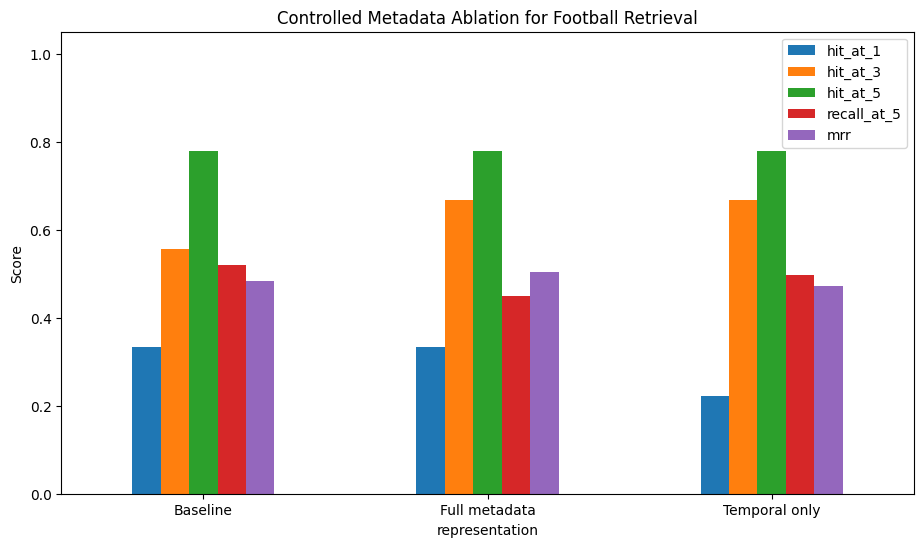

In [37]:
aggregate_metrics[
    [
        "hit_at_1",
        "hit_at_3",
        "hit_at_5",
        "recall_at_5",
        "mrr",
    ]
].plot(
    kind="bar",
    figsize=(11, 6),
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title(
    "Controlled Metadata Ablation for Football Retrieval"
)
plt.xticks(rotation=0)
plt.legend()
plt.show()

# Part IX - Temporal Query Analysis

## 31. Focus on the difficult temporal queries

These queries motivated the metadata experiment:

```text
q3 - Di María before half-time
q5 - Messi extra-time goal
q7 - Lautaro extra-time chance
```

In [38]:
TEMPORAL_QUERY_IDS = [
    "q3_di_maria_goal",
    "q5_messi_extra_time_goal",
    "q7_lautaro_extra_time",
]

temporal_query_results = evaluation_results[
    evaluation_results["query_id"].isin(
        TEMPORAL_QUERY_IDS
    )
][
    [
        "representation",
        "query_id",
        "hit@1",
        "hit@3",
        "hit@5",
        "first_relevant_rank",
        "reciprocal_rank",
        "top5_possessions",
    ]
].sort_values(
    [
        "query_id",
        "representation",
    ]
)

temporal_query_results

,representation,query_id,hit@1,hit@3,hit@5,first_relevant_rank,reciprocal_rank,top5_possessions
2,Baseline,q3_di_maria_goal,0,0,0,18,0.055556,"[25, 11, 35, 39, 23]"
20,Full metadata,q3_di_maria_goal,0,0,0,18,0.055556,"[35, 25, 18, 86, 31]"
11,Temporal only,q3_di_maria_goal,0,0,0,19,0.052632,"[25, 35, 18, 23, 86]"
4,Baseline,q5_messi_extra_time_goal,0,0,0,48,0.020833,"[218, 27, 18, 19, 23]"
22,Full metadata,q5_messi_extra_time_goal,0,0,0,15,0.066667,"[240, 218, 226, 230, 200]"
13,Temporal only,q5_messi_extra_time_goal,0,0,0,9,0.111111,"[240, 226, 202, 244, 218]"
6,Baseline,q7_lautaro_extra_time,1,1,1,1,1.000000,"[218, 221, 230, 94, 246]"
24,Full metadata,q7_lautaro_extra_time,0,1,1,3,0.333333,"[230, 233, 218, 246, 221]"
15,Temporal only,q7_lautaro_extra_time,0,1,1,3,0.333333,"[230, 233, 221, 246, 228]"


## 32. Inspect Messi's extra-time goal

This was one of the clearest baseline failures in Notebook 04.

Because the event boundaries are now identical, any rank improvement can be attributed much more confidently to the metadata text itself.

In [39]:
INSPECTION_QUERY_ID = "q5_messi_extra_time_goal"

selected_item = next(
    item
    for item in benchmark
    if item["query_id"] == INSPECTION_QUERY_ID
)

print("Query:")
print(selected_item["query"])

print("\nRelevant possessions:")
print(
    sorted(
        selected_item["relevant_possessions"]
    )
)

Query:
Argentina creates the extra-time attack that ends with Messi scoring

Relevant possessions:
[228]


In [40]:
for representation_name, (
    chunks,
    embeddings,
) in evaluation_inputs.items():

    ranked = deduplicate_by_possession(
        rank_chunks(
            selected_item["query"],
            chunks,
            embeddings,
        )
    )

    print("\n" + "=" * 100)
    print(representation_name.upper())
    print("=" * 100)

    for result in ranked[:5]:
        relevant = (
            result["possession_id"]
            in selected_item["relevant_possessions"]
        )

        print(
            f"Rank {result['possession_rank']} | "
            f"score={result['score']:.4f} | "
            f"possession={result['possession_id']} | "
            f"relevant={relevant}"
        )

        print("-" * 100)
        print(result["text"])
        print()


BASELINE
Rank 1 | score=0.6365 | possession=218 | relevant=False
----------------------------------------------------------------------------------------------------
Possession 218. Argentina.

104:26 - Argentina: Lionel Andrés Messi Cuccittini carries the ball. 104:26 - Argentina: Lionel Andrés Messi Cuccittini completes a pass to Lautaro Javier Martínez. 104:27 - Argentina: Lautaro Javier Martínez carries the ball. 104:28 - Argentina: Lautaro Javier Martínez takes a shot with an xG of 0.233. The shot outcome is Blocked. 104:28 - France: Dayotchanculle Upamecano performs a Block event. 104:28 - France: Hugo Lloris performs a goalkeeper action: Shot Faced. 104:30 - Argentina: Gonzalo Ariel Montiel recovers the ball. 104:30 - Argentina: Gonzalo Ariel Montiel takes a shot with an xG of 0.021. The shot outcome is Blocked. 104:31 - France: Raphaël Varane performs a Block event.

Rank 2 | score=0.6321 | possession=27 | relevant=False
--------------------------------------------------------

# Part X - Retrieval Diversity

## 33. Check raw Top-5 diversity

The same diagnostic used previously is retained.

In [41]:
def top_k_unique_possessions(
    query: str,
    chunks: list[dict],
    embeddings: np.ndarray,
    top_k: int = 5,
) -> int:
    """Count unique possession IDs among raw Top-K chunks."""

    ranked = rank_chunks(
        query,
        chunks,
        embeddings,
    )

    return len({
        result["possession_id"]
        for result in ranked[:top_k]
    })

In [42]:
diversity_rows = []

for item in benchmark:
    for representation_name, (
        chunks,
        embeddings,
    ) in evaluation_inputs.items():

        diversity_rows.append({
            "query_id": item["query_id"],
            "representation": representation_name,
            "unique_possessions_in_top5": (
                top_k_unique_possessions(
                    item["query"],
                    chunks,
                    embeddings,
                    top_k=5,
                )
            ),
        })

diversity_results = pd.DataFrame(
    diversity_rows
)

diversity_results.groupby(
    "representation"
)["unique_possessions_in_top5"].mean()

representation
Baseline         5.0
Full metadata    5.0
Temporal only    5.0
Name: unique_possessions_in_top5, dtype: float64

# Part XI - Decision Framework

## 34. How to decide what MatchMind should keep

The experiment now cleanly separates three possibilities.

### Keep the baseline

Prefer the baseline if metadata does not improve retrieval enough to justify the additional text.

### Keep temporal-only metadata

Prefer temporal-only metadata if it improves difficult temporal queries and aggregate retrieval without introducing important regressions.

This would mean:

```text
Period
+
Match phase
```

contain useful retrieval information while `Play pattern` adds unnecessary noise.

### Keep full metadata

Prefer full metadata only if it consistently improves retrieval beyond the temporal-only representation.

The decision should consider both:

```text
aggregate metrics
+
query-level behavior
```

rather than a single score.

## 35. What remains fixed

This notebook does not change:

```text
embedding model
220-token maximum
1-event overlap
event formatter
benchmark queries
ground truth
retrieval metrics
```

It also does not introduce:

```text
Qdrant
BM25
hybrid retrieval
reranking
generative LLM
agent framework
```

Those belong to later stages.

# Final Conclusion

This notebook performed a controlled metadata ablation study for MatchMind.

Unlike the previous metadata experiment, all three representations used exactly the same football event groups and chunk boundaries.

The only experimental variable was the information added to the chunk header:

```text
Baseline
    -> possession ID
    -> possession team

Temporal only
    -> baseline fields
    -> period
    -> match phase

Full metadata
    -> temporal fields
    -> play pattern